# Serialise Detections to a CSV File

---

[![Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Child-pi/supervision/blob/develop/docs/notebooks/serialise-detections-to-csv.ipynb)

This cookbook introduces the [sv.CSVSink](https://supervision.roboflow.com/latest/detection/tools/save_detections/#supervision.detection.tools.csv_sink.CSVSink) tool designed to write captured object detection data to file from video streams/file.

Click the `Open in Colab` button to run the cookbook on Google Colab.

In [1]:
# Clean up legacy inference package if present in the Colab session
!pip uninstall -y -q inference roboflow-workflows 2>/dev/null || true
!pip install -q rfdetr supervision trackers pandas tqdm


In [2]:
import csv
from collections import defaultdict
from typing import List

import numpy as np
import pandas as pd
from rfdetr import RFDETRSmall
import supervision as sv
from supervision.assets import VideoAssets, download_assets
from tqdm import tqdm
from trackers import ByteTrackTracker


/usr/local/lib/python3.13/dist-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


The parameters defined below are:
* `SOURCE_VIDEO_PATH` - the path to the input video
* `CONFIDENCE_THRESHOLD` - do not include detections below this confidence level
* `FILE_NAME` - write the CSV output to this file


In [3]:
SOURCE_VIDEO_PATH = download_assets(VideoAssets.PEOPLE_WALKING)
CONFIDENCE_THRESHOLD = 0.3
FILE_NAME = "detections.csv"


[2026-09-19 12:29:51] [INFO] supervision.assets.downloader - Downloading people-walking.mp4 assets


  0%|          | 0/7606633 [00:00<?, ?it/s]

As a result of executing the above `download_assets(VideoAssets.PEOPLE_WALKING)` , you will download a video file and save it at the `SOURCE_VIDEO_PATH`. Keep in mind that the video preview below works only in the web version of the cookbooks and not in Google Colab.

<video controls width="1280">
  <source src="https://media.roboflow.com/supervision/video-examples/people-walking.mp4" type="video/mp4">
</video>


## Read single frame from video

The [`get_video_frames_generator`](https://supervision.roboflow.com/develop/utils/video/#supervision.utils.video.get_video_frames_generator) enables us to easily iterate over video frames. Let's create a video generator for our sample input file and display its first frame on the screen.


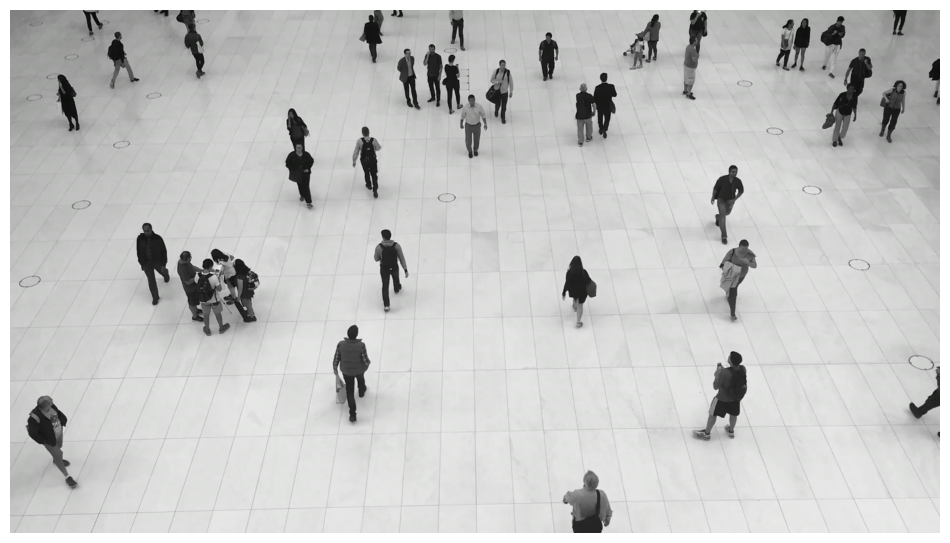

In [4]:
generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(generator)

sv.plot_image(frame, (12, 12))


## Initialize ByteTrackTracker

[ByteTrackTracker](https://trackers.roboflow.com/latest/) is a multi-object tracking algorithm from the external `trackers` package. It tracks and links detected objects across multiple frames, providing consistent IDs for each object. Initialize the `ByteTrackTracker` object.

In [5]:
byte_track = ByteTrackTracker(
    minimum_consecutive_frames=3, track_activation_threshold=CONFIDENCE_THRESHOLD
)
byte_track.reset()


## Process video and save detections to CSV file

To save detections to a CSV file, we use [`sv.CSVSink`](https://supervision.roboflow.com/latest/how_to/save_detections/#save-detections-as-csv). We iterate over the video frames using [`sv.get_video_frames_generator`](https://supervision.roboflow.com/develop/utils/video/#supervision.utils.video.get_video_frames_generator), run object detection using `RFDETRSmall`, maintain persistent object IDs using `ByteTrackTracker`, and append detections along with custom metadata like `frame_number` to `csv_sink`.

In [6]:
model = RFDETRSmall()
video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)
generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)

with sv.CSVSink(FILE_NAME) as csv_sink:
    for frame_number, frame in enumerate(tqdm(generator, total=video_info.total_frames)):
        # Model prediction: convert BGR frame to RGB
        detections = model.predict(frame[:, :, ::-1].copy(), threshold=CONFIDENCE_THRESHOLD)

        # Filter for person detections
        detections = detections[detections.data["class_name"] == "person"]

        # Update tracking IDs
        detections = byte_track.update(detections)
        detections = detections[detections.tracker_id != -1]

        # Write detections to CSV sink
        csv_sink.append(detections, custom_data={"frame_number": frame_number})


[2026-09-19 12:29:56] [INFO] rf-detr - Downloading pretrained weights for /root/.roboflow/models/rf-detr-small.pth


/root/.roboflow/models/rf-detr-small.pth:   0%|          | 0.00/368M [00:00<?, ?iB/s]

[2026-09-19 12:30:17] [INFO] rf-detr - MD5 validation successful for /root/.roboflow/models/rf-detr-small.pth


[2026-09-19 12:30:17] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-09-19 12:30:17] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-09-19 12:30:20] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-small.pth already exists with correct MD5 hash.


100%|██████████| 341/341 [08:28<00:00,  1.49s/it]


## Visualize results of detections CSV data with Pandas

Let's inspect our resulting data using Pandas.


In [7]:
df = pd.read_csv(FILE_NAME)
df


,x_min,y_min,x_max,y_max,class_id,confidence,tracker_id,class_name,frame_number,source_shape
0,1143.49940,937.545350,1243.92310,1079.19360,1,0.860401,0,person,2,[1080 1920]
1,1396.07430,703.574650,1517.27620,888.26294,1,0.781178,1,person,2,[1080 1920]
2,672.89260,636.065060,747.16750,833.61224,1,0.778270,2,person,2,[1080 1920]
3,710.80850,231.644560,766.61270,373.22684,1,0.637207,3,person,2,[1080 1920]
4,1142.99790,496.830870,1208.79160,645.26025,1,0.679890,4,person,2,[1080 1920]
...,...,...,...,...,...,...,...,...,...,...
4943,1278.05750,4.510054,1328.20510,128.09352,1,0.408175,14,person,340,[1080 1920]
4944,749.58984,95.773830,800.39087,247.06235,1,0.514880,15,person,340,[1080 1920]
4945,1869.19290,712.079900,1919.87740,835.34340,1,0.355382,24,person,340,[1080 1920]
4946,385.55600,470.709750,460.50480,634.93933,1,0.454012,26,person,340,[1080 1920]


## Convert CSV data to sv.Detections

We can parse the serialised CSV rows back into `sv.Detections` objects grouped by frame.

In [8]:
def csv_to_detections(csv_file: str) -> List[sv.Detections]:
    rows_by_frame_number = defaultdict(list)
    with open(csv_file, "r") as f:
        reader = csv.DictReader(f)
        for row in reader:
            frame_number = int(row["frame_number"])
            rows_by_frame_number[frame_number].append(row)

    detections_list = []
    for frame_number, rows in rows_by_frame_number.items():
        xyxy = []
        class_id = []
        confidence = []
        tracker_id = []
        custom_data = defaultdict(list)

        for row in rows:
            xyxy.append([float(row[key]) for key in ["x_min", "y_min", "x_max", "y_max"]])
            class_id.append(int(row["class_id"]) if row["class_id"] != "" else 0)
            confidence.append(float(row["confidence"]) if row["confidence"] != "" else 1.0)
            tracker_id.append(int(row["tracker_id"]) if row["tracker_id"] != "" else -1)

            for custom_key in row.keys():
                if custom_key in ["x_min", "y_min", "x_max", "y_max", "class_id", "confidence", "tracker_id"]:
                    continue
                custom_data[custom_key].append(row[custom_key])

        detections_list.append(
            sv.Detections(
                xyxy=np.array(xyxy, dtype=np.float32),
                class_id=np.array(class_id, dtype=int),
                confidence=np.array(confidence, dtype=np.float32),
                tracker_id=np.array(tracker_id, dtype=int),
                data=dict(custom_data)
            )
        )

    return detections_list


In [9]:
detections_list = csv_to_detections(FILE_NAME)

print(f"Frames with detections: {len(detections_list)}")
print(detections_list[0])


Frames with detections: 339
Detections(xyxy=array([[1143.4994  ,  937.54535 , 1243.9231  , 1079.1936  ],
       [1396.0743  ,  703.57465 , 1517.2762  ,  888.26294 ],
       [ 672.8926  ,  636.06506 ,  747.1675  ,  833.61224 ],
       [ 710.8085  ,  231.64456 ,  766.6127  ,  373.22684 ],
       [1142.9979  ,  496.83087 , 1208.7916  ,  645.26025 ],
       [1454.0908  ,  324.52994 , 1520.943   ,  485.51944 ],
       [ 755.9701  ,  442.5064  ,  828.54724 ,  615.23456 ],
       [ 569.52765 ,  275.44858 ,  631.52203 ,  419.06006 ],
       [1467.3357  ,  480.86075 , 1544.177   ,  651.1     ],
       [  35.285946,  800.42725 ,  142.95982 ,  991.2527  ],
       [ 257.41293 ,  443.66992 ,  328.26697 ,  611.1367  ]],
      dtype=float32), mask=None, confidence=array([0.86040145, 0.7811776 , 0.7782704 , 0.63720685, 0.6798905 ,
       0.66620004, 0.7201506 , 0.6229163 , 0.6839195 , 0.60686845,
       0.58414376], dtype=float32), class_id=array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]), tracker_id=array([ 

### Annotate Frame

Visualize frame 100 alongside the detections loaded from the CSV file.

In [10]:
FRAME_NUMBER = 100

detections = detections_list[FRAME_NUMBER]
frame_number = int(detections.data["frame_number"][0])

generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH, start=frame_number)
frame = next(generator)


### Annotate Image with Detections

Finally, we annotate the frame with [`sv.BoxAnnotator`](https://supervision.roboflow.com/latest/detection/annotators/#supervision.annotators.core.BoxAnnotator) and [`sv.LabelAnnotator`](https://supervision.roboflow.com/latest/detection/annotators/#supervision.annotators.core.LabelAnnotator).

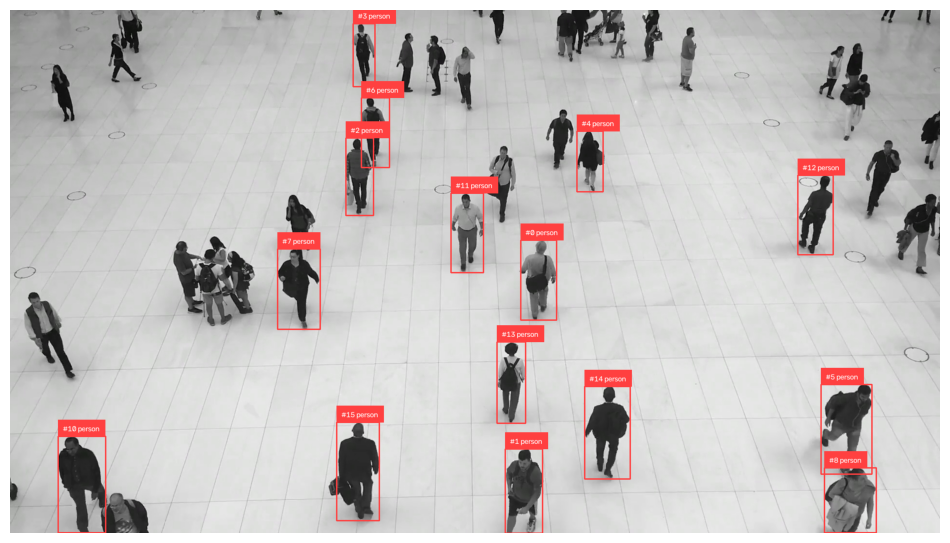

In [11]:
bounding_box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

labels = [
    f"#{tracker_id} {class_name}"
    for tracker_id, class_name in zip(detections.tracker_id, detections.data["class_name"])
]

annotated_frame = frame.copy()
annotated_frame = bounding_box_annotator.annotate(scene=annotated_frame, detections=detections)
annotated_frame = label_annotator.annotate(scene=annotated_frame, detections=detections, labels=labels)
sv.plot_image(annotated_frame, (12, 12))


## References 📚

* Supervision: https://supervision.roboflow.com
* sv.Detections: https://supervision.roboflow.com/develop/detection/core/#detections
* Save Detections to CSV: https://supervision.roboflow.com/develop/how_to/save_detections/#save-detections-as-csv
* Custom fields: https://supervision.roboflow.com/develop/how_to/save_detections/#custom-fields
* ByteTrack (external `trackers` package): https://trackers.roboflow.com/latest/
* RF-DETR: https://github.com/roboflow/rf-detr
